In [ ]:
#Librerias necesarias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from github import Github
import os
#import pyvo
#import astropy
from astropy.coordinates import SkyCoord 
from astropy.io import fits
#from astroquery.ipac.ned import Ned
import astropy.units as u
from astropy import coordinates
from astropy.coordinates import Angle, Latitude, Longitude 
import numpy as np

In [9]:
from pathlib import Path

DATA = Path('../data/')

# Offline handling

Copied the whole repository https://github.com/alondrabunny261/SMOG-sources into `../data/external/` using:
```
cd data/external
git clone --depth 1 https://github.com/alondrabunny261/SMOG-sources.git
```

and copied file `All_Sources_SMOG.xlsx` into `../data/external`

In [44]:
#My table
source_table = pd.read_excel(DATA / "external/All_Sources_SMOG.xlsx")
source_table


,l,b,type,morphology,description,path
0,100.950976,3.086404,Fuente,Alargada,"Fuente pequeña, rojiza y tenue. Orientación as...","Fuentes/100.9509758,3.0864039.fits"
1,100.990362,2.964779,Fuente,Alargada,"Fuente rojiza gordita mediana, solo se ve la m...","Fuentes/100.9903617,2.9647789.fits"
2,100.999299,2.936191,Fuente,Redonda,Fuente grande rojiza con centro azulado.,"Fuentes/100.9992993,2.9361912.fits"
3,101.016638,3.047641,Fuente,Espiral,"Fuente azulada y rojiza, alargada con centro b...","Fuentes/101.0166378,3.0476406.fits"
4,101.016909,3.047321,Fuente,Espiral,Fuente grande con centro azulado y brazos espi...,"Fuentes/101.0169092,3.0473209.fits"
...,...,...,...,...,...,...
2481,104.487141,1.230553,Fuente_Puntual,NaN,NaN,"Fuentes_Puntuales/104.48714100000001,1.230553...."
2482,104.487322,1.279389,Fuente_Puntual,NaN,NaN,"Fuentes_Puntuales/104.48732199999999,1.2793889..."
2483,104.487362,1.255139,Fuente_Puntual,NaN,NaN,"Fuentes_Puntuales/104.487362,1.255139.fits"
2484,104.487491,1.268428,Fuente_Puntual,NaN,NaN,"Fuentes_Puntuales/104.487491,1.268428.fits"


In [90]:
source_table[['type','morphology']].value_counts(dropna=False)

type            morphology
Fuente_Puntual  NaN           1000
No_Fuente       NaN            709
Fuente          Alargada       408
                Redonda        211
                Difusa         116
                Espiral         18
                Otra            15
                NaN              9
Name: count, dtype: int64

In [ ]:
def load_data_from_fits(path, channels=[0,1,2,3,4]):
  hdul = fits.open(path, mode="readonly", memmap=False)  # possibly works
  #print("## HDU info:")
  #hdul.info()
  
  #header = hdul[0].header

  def map_band(band):
    if isinstance(band, (int, float)):
        return band
    if isinstance(band, str):
        mapping = dict(
          band_8_micron=0,
          band_4_5_micron=1,
          band_3_6_micron=2,
          band_5_1_micron=3,
          RGB=4,   # RGB appears with only 1 channel??
        )
        return mapping[band]
    raise ValueError('band should be integer or valid string')

  data_list = [ hdul[0].data[map_band(channel_name)] for channel_name in channels]

  #Data arrays of different wavelenghts
  #data_8_micron   =  hdul[0].data[0]   # hardcoded. Should have some metadata to confirm correct type
  #data_4_5_micron =  hdul[0].data[1]
  #data_3_6_micron =  hdul[0].data[2]
  #data_5_1_micron =  hdul[0].data[3]
  #data_RGB        =  hdul[0].data[4]
  
  #print("Data shape:", data_8_micron.shape)

  return data_list

In [ ]:
FITS_ROOT = DATA / 'external/SMOG-sources/'

path = FITS_ROOT / source_table.iloc[0].path
hdul = fits.open(path, mode="readonly", memmap=False)  # possibly works
print(f"glon,glat={hdul[0].header['CRVAL1']},{hdul[0].header['CRVAL2']}")
print(hdul[0].header)

glon,glat=100.9509758,3.0864039
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    3 / number of array dimensions                     NAXIS1  =                  100                                                  NAXIS2  =                  100                                                  NAXIS3  =                    6                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =                 49.5 / Pixel coordinate of reference point            CRPIX2  =                 49.5 / Pixel coordinate of reference point            CDELT1  =      -0.000166666665 / [deg] Coordinate increment at reference point  CDELT2  =       0.000166666665 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and value        CUNIT2  

l                                         102.852703
b                                           1.403769
type                                       No_Fuente
morphology                                       NaN
description                                      NaN
path           No_Fuentes/102.8527025,1.4037692.fits
Name: 1000, dtype: object

auto_scale=True


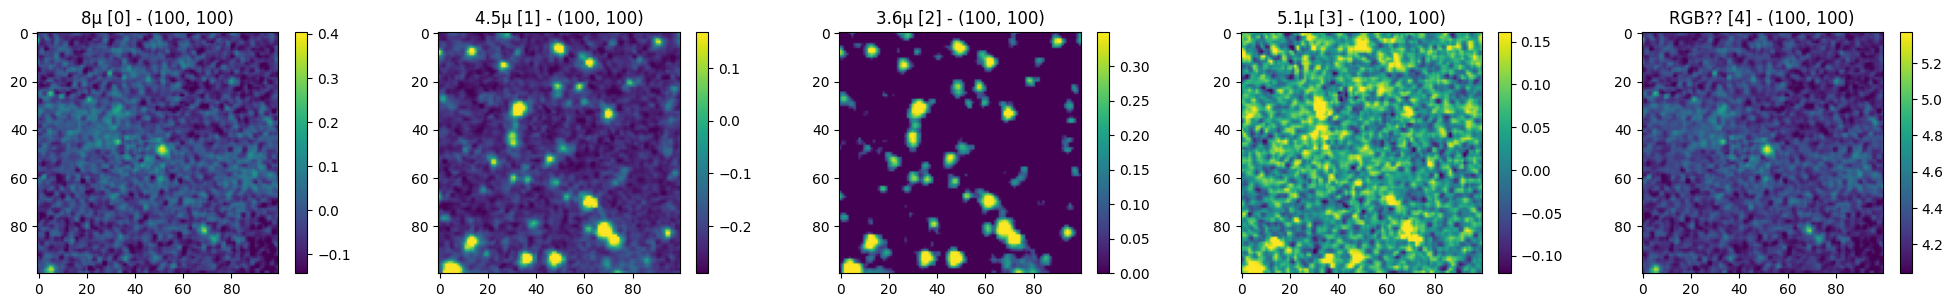

In [86]:
idx = 1000
item = source_table.iloc[idx]
path = FITS_ROOT / item.path
data = load_data_from_fits( path, [0,1,2,3,4] )
names=['8µ [0]','4.5µ [1]','3.6µ [2]','5.1µ [3]','RGB?? [4]','segmented [5]']
N=len(data)

display( item )

auto_scale = True
print(f'auto_scale={auto_scale}')

fig,axes = plt.subplots(1,N,figsize=(20,3))
for i in range(N):
  plt.sca(axes[i])

  D = data[i]
  plt.imshow(D)

  if (auto_scale):
    D_crop = D[40:60,40:60]
    vmin,vmax = np.nanmin(D_crop),np.nanmax(D_crop)
    plt.clim(vmin,vmax)

  channel_name = names[i]
  plt.title(f'{channel_name} - {data[i].shape}')
  plt.colorbar()
plt.tight_layout()

# Online handling (individual download from github)

In [ ]:
!pip install PyGithub

In [ ]:
#Works for Python 3.6.15

In [ ]:
# Define .env file with the following information
#ACCESS_TOKEN = "xxxxx"
#REPO_OWNER = "alondrabunny261"
#REPO_NAME = "SMOG-sources"

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
ACCESS_TOKEN = os.getenv("GITHUB_TOKEN")
REPO_OWNER = os.getenv("REPO_OWNER")
REPO_NAME = os.getenv("REPO_NAME")

In [ ]:
# Open FIT files found in github repository
def open_fits_from_content(content, temp_filename="temp.fits"):
    """
    Given a PyGithub ContentFile (for a .fits file), return an HDUList.
    Tries in-memory first; if that fails (especially for compressed FITS),
    writes to disk and opens from there.
    """
    raw = content.decoded_content  # bytes

    # Try in-memory
    try:
        bio = io.BytesIO(raw)
        bio.seek(0)
        hdul = fits.open(bio, mode="readonly", memmap=False)  # possibly works
        return hdul
    except Exception as e:
        # Fallback: write to disk
        with open(temp_filename, "wb") as f:
            f.write(raw)
        hdul = fits.open(temp_filename)
        # Optionally remove the temp file now or later
        os.remove(temp_filename)
        return hdul



In [ ]:
g = Github(ACCESS_TOKEN)
repo = g.get_repo(f"{REPO_OWNER}/{REPO_NAME}")

Opening: Fuentes/100.9509758,3.0864039.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/100.9509758,3.0864039.fits
Alargada


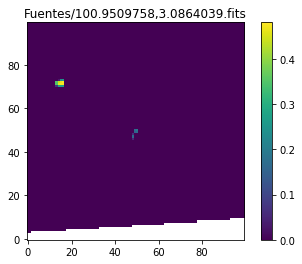

Fuentes/100.9509758,3.0864039.fits
Opening: Fuentes/100.9903617,2.9647789.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/100.9903617,2.9647789.fits
Alargada


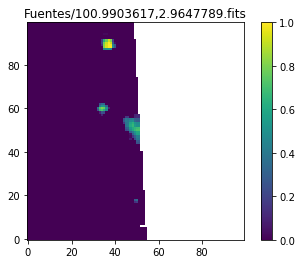

Fuentes/100.9903617,2.9647789.fits
Opening: Fuentes/100.9992993,2.9361912.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/100.9992993,2.9361912.fits
Fuentes/100.9992993,2.9361912.fits
Opening: Fuentes/101.0166378,3.0476406.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.0166378,3.0476406.fits
Fuentes/101.0166378,3.0476406.fits
Opening: Fuentes/101.0169092,3.0473209.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.0169092,3.0473209.fits
Fuentes/101.0169092,3.0473209.fits
Opening: Fuentes/101.0177674,3.2457972.fits
  HDU info:
Filename:

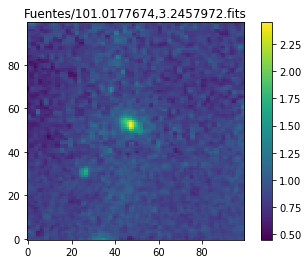

Fuentes/101.0177674,3.2457972.fits
Opening: Fuentes/101.0182827,3.2460297.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.0182827,3.2460297.fits
Alargada


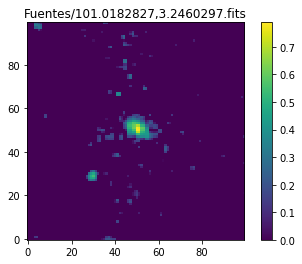

Fuentes/101.0182827,3.2460297.fits
Opening: Fuentes/101.0465589,3.0414778.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (75, 100, 6)   float64   
Data shape: (100, 75)
Fuentes/101.0465589,3.0414778.fits
Alargada


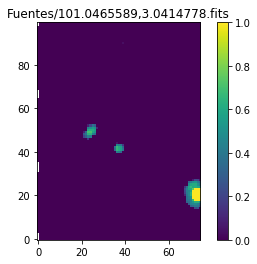

Fuentes/101.0465589,3.0414778.fits
Opening: Fuentes/101.0469534,3.0411659.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.0469534,3.0411659.fits
Alargada


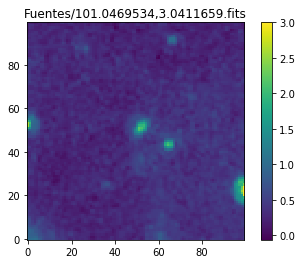

Fuentes/101.0469534,3.0411659.fits
Opening: Fuentes/101.0568032,3.0330028.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.0568032,3.0330028.fits
Fuentes/101.0568032,3.0330028.fits
Opening: Fuentes/101.1889279,3.2613769.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.1889279,3.2613769.fits
Alargada


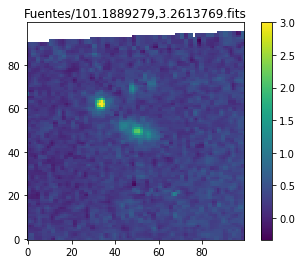

Fuentes/101.1889279,3.2613769.fits
Opening: Fuentes/101.2065033,3.062548.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.2065033,3.062548.fits
Fuentes/101.2065033,3.062548.fits
Opening: Fuentes/101.2112266,2.8523826.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.2112266,2.8523826.fits
Alargada


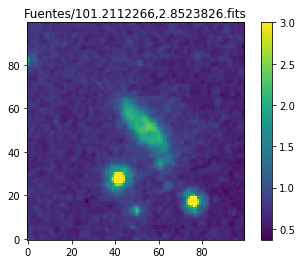

Fuentes/101.2112266,2.8523826.fits
Opening: Fuentes/101.2346802,3.1977211.fits
  HDU info:
Filename: temp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   (100, 100, 6)   float64   
Data shape: (100, 100)
Fuentes/101.2346802,3.1977211.fits
Fuentes/101.2346802,3.1977211.fits


KeyboardInterrupt: 

In [ ]:
for index,t in enumerate(source_table.type):
    
    file = source_table.path[index]
        
    content = repo.get_contents(file)
    
    if content.type == "file" and content.path.lower().endswith(".fits"):
        
        print("Opening:", content.path)
        hdul = open_fits_from_content(content)
        print("  HDU info:")
        hdul.info()
        
        header = hdul[0].header

        #Data arrays of different wavelenghts
        data_8_micron   =  hdul[0].data[0]
        data_4_5_micron =  hdul[0].data[1]
        data_3_6_micron =  hdul[0].data[2]
        data_5_1_micron =  hdul[0].data[3]
        data_RGB        =  hdul[0].data[4]
        
        print("Data shape:", data_8_micron.shape)


        ##################################################################################################
        #Galaxy Sources
        if t == "Fuente":
            print(file)
            
            data_segmented  =  hdul[0].data[5]
            
            morphology = source_table.morphology[index]
            
            if morphology == "Alargada":
                
                print(morphology)
                
                #Plotting_This specifically only plots elongated sources at 8 microns
                plt.imshow(data_8_micron, origin="lower")
                plt.colorbar()
                plt.title(content.path)
                plt.show()
  
        ##########################################################################################################
        #Not Galaxy Sources
        elif t == "No_Fuente" or t == "Fuente_Puntual":
            print(file)

        hdul.close()  # close
        print(content.path)
